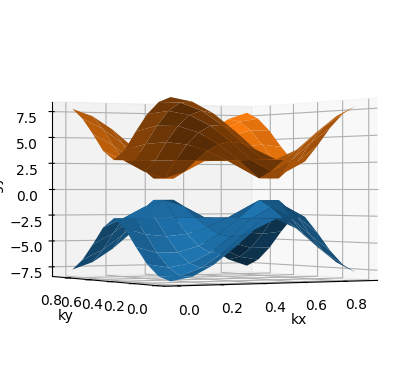

0 [0]
0 [0]


In [1]:
import numpy as np
import sys,os
diage_path = os.environ.get('DIAGE','')

path = diage_path+'/class'
sys.path.append(path)
from ClassDiagE import Crystal as cr
from ClassDiagE import FHamiltonian as fh
from ClassDiagE import BHamiltonian as bh
from ClassDiagE import FT_grid as ft
from ClassDiagE import Method
from ClassDiagE import Impurity
path = diage_path+'/modules'
sys.path.append(path)
import DiagE

# %% [markdown]
# ## Generate Crystal & Basic system

# %%
latt = [[1.0,0.0,0.0],[1/2,np.sqrt(3)/2,0.0],[0.0,0.0,10.0]]
pos = [[1/3,1/3,1/2],[2/3,2/3,1/2]]

Graphene = cr(latt,pos)
grid = [10,10,1]
Graphene.Kpoint(meshgrid=grid)

# %%
Gf = fh(Graphene,1)
Gb = bh(Graphene,Gf)

orb_option1 = [0,1]
orb_option2 = [1,1]

Gf.set_basis_index(orb_option1)
Gf.set_basis_index(orb_option2)

Gb.set_basis_index(orb_option1)
Gb.set_basis_index(orb_option2)

# %% [markdown]
# ## Construct Non-interacting Hamiltonian

# %%
t = -2.7
e = 0.0
Gf.On_site_list([e,e])

Gf.Hoppinglist(t,0,1,[0,0,0])
Gf.Hoppinglist(t,1,0,[1,0,0])
Gf.Hoppinglist(t,1,0,[0,1,0])
Gf.Hamiltonian()
Ham_tb = Gf.Ham_tb
# %% [markdown]
# ### Visualization of tight_binding Hamiltonian

# %%
energy = Gf.diagonalize(Ham_tb)
Gf.visualization(energy)

# %% [markdown]
# ## Construct the interacting Hamiltonian

# %%
U = 5
option1 = {"KorS" : "S", "value" : [U,0,0], "site" : 0, "orbital" : [0]}
option2 = {"KorS" : "S", "value" : [U,0,0], "site" : 0, "orbital" : [1]}

Gb.local_interacting(option1)
Gb.local_interacting(option2)

V = 2

Gb.set_int_amp(V,1,0,[1,0,0])
Gb.set_int_amp(V,1,0,[0,1,0])
Gb.set_int_amp(V,0,1,[0,0,0])

Gb.gen_nl_int_ham()
Gb.Combine_interaction()


# %% [markdown]
# ## Hartree-Fock approximation

# %% [markdown]
# ### Construct FT grid & Method class

# %%
beta = 38.0
size = 1000
FT = ft(beta,size)

FT.Omega()
FT.Tau()
FT.Nu()



# %% [markdown]
# ### SCF loop of Hartree-Fock

# %%
iter = 100
Nt = 1
mix = 0.1
# print('Hartree-Fock start')
# Hmat_hf, Sigma_H, Sigma_F, n, mu_hf = GM.Hartree_Fock(iter,Ham_tb,Nt,mix)
# print('Hartree-Fock finish')
# # %%
# energy_hf = Gf.diagonalize(Hmat_hf)

In [2]:
Gi = Impurity(Gf,Gb,FT)

In [3]:
Gb.b2f

[[0, 0], [1, 1]]

In [4]:
ind_dict = {"1":[[[0,0]],[[1,0]]]}
Gi.projector(ind_dict)

0 0 0 0
1 0 1 1


In [5]:
Gi.fprojector.shape

(2, 1, 1, 2)

In [6]:
Gb.imp_dict

{'1': [[0], [1]]}

In [7]:
for key, val in ind_dict.items():
    atom = 0
    for orb_list in val:
        print(orb_list[0])
        for orb in orb_list:
            print(orb)
            if orb == val[0][0]:
                atom = orb[0]
                print(atom)
            if atom != orb[0]:
                print("Different atoms are involved in the same space")

[0, 0]
[0, 0]
0
[1, 0]
[1, 0]
Different atoms are involved in the same space


In [8]:
Gi.fprojector[:,:,:,0]

array([[[1.+0.j]],

       [[0.+0.j]]])

In [9]:
GM = Method(Gf,Gb,FT,Gi)

In [10]:
Ham_p = DiagE.projection.flatstc(Ham_tb,Gi.fprojector[...,0])

In [11]:
Ham_p

array([[[0.+0.j]]])

In [12]:
Hmat_hf, Sigma_H, Sigma_F, n, mu_hf = GM.Hartree_Fock(1,Ham_tb,Nt,mix)

iteration : 1 
 Criteria 
 0.1129183918137878 
 chemical potential : 9.209515782750941
Notice: Broadening schemes will be turned off from the 1-th iteration.


In [13]:
Ham_p = DiagE.projection.flatstc(Hmat_hf,Gi.fprojector[...,0])

In [14]:
print(Ham_p,Hmat_hf[0,0,0,0])

[[[-0.7103632+2.21177243e-18j]]] (-0.7103632044230803+2.2117724318704297e-18j)


In [15]:
Ham_e = DiagE.embedding.flatstc(Hmat_hf.shape[3],Ham_p,Gi.fprojector[...,0])

In [16]:
for ik in range(100):
    for js in range(1):
        for iorb in range(1):
            err = Ham_e[iorb,iorb,js,ik]-Hmat_hf[iorb,iorb,js,ik]
            if abs(err)>= 1.0e-6:
                print(iorb,js,ik,abs(err),Ham_e[iorb,iorb,js,ik],Hmat_hf[iorb,iorb,js,ik])


In [17]:
Hmat_hf[0,0,0]

array([-0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.21177243e-18j,
       -0.7103632+2.21177243e-18j, -0.7103632+2.2117724

In [18]:
Gi.fprojector.shape

(2, 1, 1, 2)

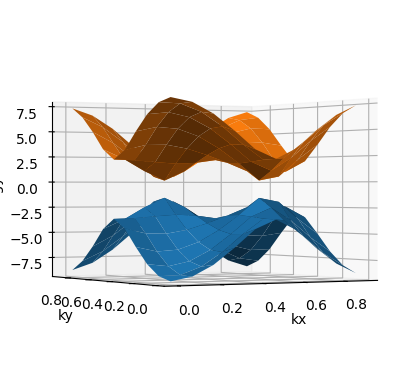

In [19]:
energy = Gf.diagonalize(Hmat_hf)
Gf.visualization(energy)

In [20]:
Gf.Energy_imp(Hmat_hf,mu_hf,Gi.fprojector)

In [21]:
Gf.E_imp

array([[[[-9.91987899+2.21177243e-18j, -9.91987899+5.30825384e-18j]]]])

In [22]:
# temp = np.zeros((2,2,1,100),dtype=complex)
# temp = Hmat_hf
# for ik in range(100):
#     for js in range(1):
#         for iorb in range(2):
#             temp = Hmat_hf[iorb,iorb,js,ik] - mu_hf
# energy = Gf.diagonalize(temp)
# Gf.visualization(energy)
# tempmat = np.zeros((1,1,1,2),dtype=complex)
# for ii in range(2):
#     tempmat[...,ii] = DiagE.projection.flatstc(temp,Gi.fprojector[...,ii])

In [23]:
E_imp_p = Gf.FimpconvertLocStc(Gf.E_imp,0)

In [24]:
tempmat = np.array(E_imp_p[...,0],dtype=float)

/var/folders/38/tp9jw_cn4ng7yg82wfyfpdk40000gn/T/ipykernel_66913/2042548211.py:1: ComplexWarning: Casting complex values to real discards the imaginary part
  tempmat = np.array(E_imp_p[...,0],dtype=float)


In [25]:
tempmat.shape

(1, 1, 1)

In [26]:
Gf.Energy_imp(Hmat_hf,mu_hf,Gi.fprojector)

In [27]:
Gf.E_imp

array([[[[-19.12939477+2.21177243e-18j, -19.12939477+5.30825384e-18j]]]])

In [28]:
G_temp = DiagE.bare.flatfreq(Hmat_hf,FT.omega)
G_loc = np.zeros((Gi.fprojector.shape[1],Gi.fprojector.shape[1],Gf.ns,size,len(Gf.prob_space["1"])),dtype=complex,order='F')
for ii in range(G_loc.shape[4]):
    G_loc[:,:,:,:,ii] = DiagE.projection.flatdyn(G_temp,Gi.fprojector[:,:,:,ii])

In [29]:
Gi.fprojector.shape

(2, 1, 1, 2)

In [30]:
G_loc.shape

(1, 1, 1, 1000, 2)

In [31]:
tempmat = np.zeros((2,2,1,100,1000),dtype=complex)
tempmat1 = np.zeros((2,2,1,100,1000,2),dtype=complex)
tempmat2 = np.zeros((2,2,1,100,1000),dtype=complex)
for ii in range(G_loc.shape[4]):
    tempmat1[...,ii] = DiagE.embedding.flatdyn(100,G_loc[...,ii],Gi.fprojector[...,ii])
    tempmat += tempmat1[...,ii]
    tempmat2 += DiagE.embedding.flatdyn(100,G_loc[...,ii],Gi.fprojector[...,ii])

In [32]:
G_temp[:,:,0,0,0]

array([[ 0.0645277 -0.00040963j, -0.0281192 -0.00028249j],
       [-0.02810677+0.00088243j,  0.0645277 -0.00040963j]])

In [33]:
tempmat[:,:,0,0,0]

array([[0.05604594-0.00027893j, 0.        +0.j        ],
       [0.        +0.j        , 0.05604594-0.00027893j]])

In [34]:
tempmat2[:,:,0,0,0]

array([[0.05604594-0.00027893j, 0.        +0.j        ],
       [0.        +0.j        , 0.05604594-0.00027893j]])

In [35]:
G_loc.shape

(1, 1, 1, 1000, 2)

In [36]:
Sigma_DC = Gf.DC_self_energy(G_loc,Gb,Gi)

In [32]:
Sigma_DC.shape

(1, 1, 1, 1000, 2)

In [38]:
Sigma_DC_p = Gf.FimpconvertLocDyn(Sigma_DC,0)

In [39]:
Sigma_DC_p.shape

(1, 1, 1, 1000, 1)

In [33]:
equiv = np.eye(5,5)

In [34]:
equiv

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

In [35]:
temp = equiv[:3,:3]
temp

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [36]:
# temp = GM.DMFT(1,Ham_tb,Nt,0.01,None,0,0,equiv)

In [40]:
import json 
obsjson = json.load(open('./params.obs.json'))
partition = obsjson['partition']

In [42]:
sigma_bare = {}
for key, val in partition["self-energy"].items():
    templist = []
    for ii in range(len(val['function']['real'])):
        templist.append(val['function']['real'][ii]+1j*val['function']['imag'][ii])
    sigma_bare[key] = templist

In [44]:
Sigma_bare = Gf.read_dict_LocDyn(np.array([[1]]),sigma_bare)

In [48]:
cutoff = 50

In [60]:
def func(x,y,w1,temperature,cutoff):
    
    norb = y.shape[0]
    ns = y.shape[2]
    nft = y.shape[3]
    ynew = np.zeros((norb,norb,ns,nft),dtype=complex,order='F')
    w0 = (1-3*w1)*np.pi*temperature
    width_array = w0+w1*x
    cnt = 0
    for x0 in x:
        if (x0>cutoff+(w0+w1*cutoff)*3.0):
            ynew[...,cnt] = y[...,cnt]
        else:
            if ((x0>3*width_array[cnt])and((x[-1]-x0)>3*width_array[cnt])):
                dist = 1.0/np.sqrt(2*np.pi)/width_array[cnt]*np.exp(-(x-x0)**2/2.0/width_array[cnt]**2)
                
                for js in range(ns):
                    for iorb in range(norb):
                        for jorb in range(norb):
                            ynew[iorb,jorb,js,cnt] = sum(dist*y[iorb,jorb,js])/sum(dist)
            else:
                ynew[...,cnt] = y[...,cnt]
        cnt += 1
    return ynew

In [61]:
A = func(FT.omega,Sigma_bare,0.05,1/FT.beta,cutoff)

(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)
(1000,)


In [59]:
cnt = 0
for x0 in FT.omega:
    cnt +=1
print(cnt)

1000


In [37]:
e = [[1],[1,1,2]]
for ii in range(len(e)):
    temp = np.diag(e[ii])
    print(temp)

[[1]]
[[1 0 0]
 [0 1 0]
 [0 0 2]]


In [38]:
# equiv = np.array([[1,0],[0,1]])
equiv = np.array([[1]])
E_imp_p = Gf.FimpconvertLocStc(Gf.E_imp,0)
print(E_imp_p)
E_dict = Gf.write_dict_LocStc(equiv,E_imp_p[...,0])

[[[[-19.12939477+3.76001313e-18j]]]]


In [39]:
E_dict[1]

[(-19.129394769924943+3.760013134179735e-18j)]

In [40]:
E_imp_p2 = Gf.read_dict_LocStc(equiv,E_dict)

In [41]:
E_imp2 = Gf.FimpconvertLocStc(E_imp_p2,1)

In [42]:
for ispace in range(2):
    for js in range(1):
        for iorb in range(1):
            for jorb in range(1):
                err = Gf.E_imp[iorb,jorb,js,ispace]-E_imp2[iorb,jorb,js,ispace]
                if abs(err)<=1.0e-6:
                    print(iorb,jorb,js,ispace,abs(err),Gf.E_imp[iorb,jorb,js,ispace],E_imp2[iorb,jorb,js,ispace])

0 0 0 0 1.548240702309302e-18 (-19.129394769924943+2.2117724318704327e-18j) (-19.129394769924943+3.760013134179735e-18j)
0 0 0 1 1.5482407023093028e-18 (-19.129394769924943+5.3082538364890375e-18j) (-19.129394769924943+3.760013134179735e-18j)


In [44]:
Gf.hybridisation(FT.omega,E_imp_p[...,0],G_loc[...,0],Sigma_DC[...,0])

In [45]:
Gb.imp_dict['1']

[[0], [1]]

In [ ]:
V_loc = Gb.Convert_4_2(Gb.V_loc,0)

In [50]:
def func(key):
    V_loc_temp = Gb.Convert_4_2_LocStc(Gb.V_loc,0)
    orb = Gb.imp_dict[key][0]
    norb = len(orb)
    ns = Gb.ns
    V_loc = np.zeros((norb,norb,norb,norb,ns,ns),dtype=complex)
    for js in range(ns):
        for ks in range(ns):
            for i in orb:
                for j in orb:
                    for k in orb:
                        for l in orb:
                            V_loc[i,j,k,l,js,ks] = V_loc_temp[i,j,k,l,js,ks]
    
    nimp_orb = V_loc.shape[0]
    U = np.zeros(nimp_orb**4*2**4,dtype=float)
    index = 0
    for sl in range(2):
        for l in range(nimp_orb):
            for sk in range(2):
                for k in range(nimp_orb):
                    for sj in range(2):
                        for j in range(nimp_orb):
                            for si in range(2):
                                for i in range(nimp_orb):
                                        
                                        
                                    if(sj==sk and si==sl):
                                        val=V_loc[i,j,k,l,0,0].real
                                        val=abs(val)
                                        if(val > 0.001):
                                            U[index]=val
                                    index=index+1
    return U

In [51]:
U = func('1')

In [52]:
U

array([5., 0., 0., 0., 0., 0., 5., 0., 0., 5., 0., 0., 0., 0., 0., 5.])

In [ ]:
Gf.hyb[...,0]

array([[[[1.28043696+0.05353698j, 1.28019129+0.04129256j,
          1.2797003 +0.02905982j, 1.27896467+0.01684653j,
          1.27798545+0.00466038j, 1.276764  -0.00749097j,
          1.27530204-0.0196j    , 1.27360158-0.03165924j,
          1.27166499-0.0436614j , 1.26949491-0.0555993j ,
          1.2670943 -0.06746592j, 1.26446638-0.07925443j,
          1.26161469-0.09095818j, 1.25854297-0.10257072j,
          1.25525524-0.11408582j, 1.25175575-0.12549747j,
          1.24804894-0.13679991j, 1.24413949-0.1479876j ,
          1.24003222-0.15905527j, 1.23573214-0.1699979j ,
          1.2312444 -0.18081073j, 1.2265743 -0.19148927j,
          1.22172723-0.2020293j , 1.21670871-0.21242686j,
          1.21152433-0.22267829j, 1.20617976-0.23278016j,
          1.2006807 -0.24272933j, 1.19503292-0.25252292j,
          1.18924221-0.26215833j, 1.18331437-0.27163319j,
          1.1772552 -0.28094541j, 1.17107048-0.29009313j,
          1.16476598-0.29907475j, 1.15834743-0.30788889j,
          1.15

In [ ]:
Gf.hyb.shape

(1, 1, 1, 1000, 1)

In [ ]:
hyb_dict = Gf.write_dict_LocDyn(equiv,Gf.hyb)

In [ ]:
hyb_2 = Gf.read_dict_LocDyn(equiv,hyb_dict)

ValueError: setting an array element with a sequence. The requested array would exceed the maximum number of dimension of 1.

In [ ]:
a = 0
for val in Gf.prob_space.values():
    a += len(val)
a

2

In [ ]:
hyb_2.shape

(1, 1, 1, 1000, 1)

In [ ]:
print(type(E_imp.shape[0]),E_imp.shape[0])
a = np.ones(E_imp.shape[0]*2,dtype=complex).tolist()
a

<class 'int'> 1


[(1+0j), (1+0j)]

In [ ]:
b = np.ones(E_imp.shape[0]*2,dtype=complex)
for ii in range(len(a)):
    if ii < E_imp.shape[0]:
        b[ii]*=0.5
    elif ii>= E_imp.shape[0]:
        b[ii]*=-0.5

b

array([ 0.5+0.j, -0.5+0.j])

In [ ]:
Sigma_DC[:,:,:,0]

array([[[[0.00360973-0.06024098j, 0.00721946-0.12048196j]]]])

In [ ]:
Sigma_DC[...,0,0]

array([[[0.00360973-0.06024098j]]])

In [ ]:
Sigma_DC.shape

(1, 1, 1, 1000, 2)

In [ ]:
Gi.fprojector.shape

(2, 1, 1, 2)

In [ ]:
for ispace in range(2):
    tempmat += DiagE.embedding(100,Sigma_DC[...,ispace],Gi.fprojector[...,ispace])

/var/folders/38/tp9jw_cn4ng7yg82wfyfpdk40000gn/T/ipykernel_79115/808419817.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tempmat += DiagE.embedding(100,Sigma_DC[...,ispace],Gi.fprojector[...,ispace])
/var/folders/38/tp9jw_cn4ng7yg82wfyfpdk40000gn/T/ipykernel_79115/808419817.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  tempmat += DiagE.embedding(100,Sigma_DC[...,ispace],Gi.fprojector[...,ispace])


error: (shape(projector, 0) == norb) failed for 1st keyword norb: flocstc:norb=1

In [ ]:

Gf.hybridisation(FT.omega,G_loc,Sigma_DC)

TypeError: FHamiltonian.hybridisation() missing 1 required positional argument: 'Sigma'

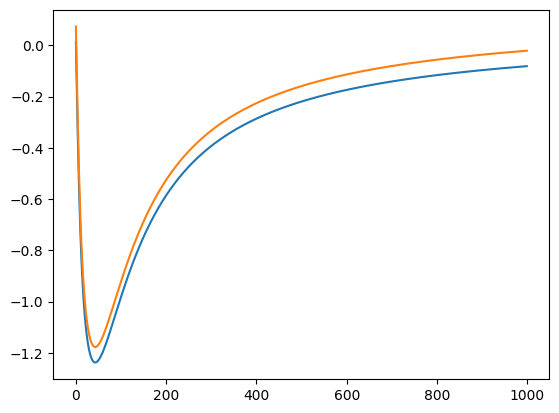

In [ ]:
import matplotlib.pyplot as plt
hyb = Gf.hyb
hyb_imag = np.imag(hyb)
hyb_real = np.real(hyb)

plt.plot(hyb_imag[0,0,0,:])
# plt.ylim(-4,2)

In [ ]:
equiv = np.array([[1,0],[0,1]])
GM.write_ctqmc_params(0,0,Gf.E_imp[:,:,:,0],0,equiv)

9.919878987174023 <class 'numpy.float64'>


/Users/moseongjun/Desktop/DiagE/class/ClassDiagE.py:3199: ComplexWarning: Casting complex values to real discards the imaginary part
  E_imp = np.array(E_imp,dtype=float)


In [ ]:
Gf.hyb[...,0].shape

(1, 1, 1, 1000)

In [ ]:
hyb_dict = Gf.write_dict_LocDyn(equiv,Gf.hyb[...,0])

IndexError: index 1 is out of bounds for axis 0 with size 1

In [ ]:
GM.write_hyb_json(hyb_dict)

In [ ]:

imp = Gf.write_dict_LocStc(equiv,E_imp)

In [ ]:
len(imp[1])

1

In [ ]:
E_imp2 = Gf.read_dict_LocStc(equiv,imp)

In [ ]:
E_imp2[:,:,0]

array([[-9.91987899+1.08376849e-17j,  0.        +0.00000000e+00j],
       [ 0.        +0.00000000e+00j, -9.91987899+1.08376849e-17j]])

In [ ]:
hyb_dict = Gf.write_dict_LocDyn(equiv,hyb)
hyb_dict.keys()

dict_keys([1])

In [ ]:
a = GM.DMFT(1,Hmat_hf,1,0.1,equiv=equiv)

/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE.py:859: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if (self.ns is not 1):
/home/momichael98/temp/Fortran/DiagE/class/ClassDiagE.py:859: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if (self.ns is not 1):


ValueError: DiagE.DiagE.dyson.flatdyn: failed to create array from the 2nd argument `sig` -- 4-th dimension must be fixed to 1 but got 1000

In [ ]:
hyb2 = Gf.read_dict_LocDyn(equiv,hyb_dict)
hyb2.shape

ValueError: setting an array element with a sequence. The requested array would exceed the maximum number of dimension of 1.

In [ ]:
def find_positions(array, value):
    positions = []
    for row_index, row in enumerate(array):
        for col_index, col_value in enumerate(row):
            if col_value == value:
                positions.append([row_index, col_index])
    return positions

In [ ]:
def temp(a,E):
    ns = E.shape[2]
    Nind = np.amax(a)
    print(Nind)
    E_dict = {}    
    
        
    for ind in range(0,Nind):
        E_dict[ind+1] = []
        val = ind+1
        pos = find_positions(a,val)
        print(pos)
    
    
        for js in range(ns):    
        # for ii, jj in pos:
         
            e = 0
            for ii, jj in pos:
            # for js in range(ns):
                print(ii,jj,js)
                e += E[ii,jj,js]
            e/=len(pos)
            E_dict[ind+1].append(e.tolist())
            


    return E_dict

In [ ]:
a = np.array([[1,0],[0,2]])
test = temp(a,E_imp)

2
[[0, 0]]
0 0 0
[[1, 1]]
1 1 0


In [ ]:
test[1][0]

(-9.919878987174023+6.375108774214775e-18j)

In [ ]:
def temp2(a,E):
    size = len(a)
    ns = len(E[1])
    print(ns)
    e = np.zeros((size,size,ns),dtype=complex)

    Nind = np.amax(a)
    
    for js in range(2):
        for ind in range(0,Nind):
            val = ind+1
            pos = find_positions(a,val)
            
            for ii,jj in pos:
                
                e[ii,jj,js] = E[ind+1][js]
    return e
        

In [ ]:
E = temp2(a,test)

1


IndexError: list index out of range

In [ ]:
E.shape

(2, 2, 2)

In [ ]:
test2 = temp(a,hyb)

2
[[0, 0]]
0 0 0
0 0 1
[[1, 1]]
1 1 0
1 1 1


In [ ]:
len(test2[1][0])

NameError: name 'test2' is not defined

In [ ]:
plt.plot(np.real(test2[1][0]))

NameError: name 'test2' is not defined

In [ ]:
hyb[:,:,:,-1]

array([[[0.00283352-0.02821965j],
        [0.00048459-0.00052542j]],

       [[0.00034615+0.00062535j],
        [0.00055785-0.02835601j]]])

In [ ]:
GM.write_ctqmc_params(0,0,E_imp,V)

TypeError: write_ctqmc_params() missing 1 required positional argument: 'equiv'

In [ ]:
Gb.orboption

{'KorS': 'S', 'params': {'F0': 5, 'F2': 0, 'F4': 0}}

In [ ]:
e = []
for j in range(E_imp.shape[2]):
    for i1 in range(E_imp.shape[0]):
        for i2 in range(E_imp.shape[0]):
            e.append(E_imp[i1,i2,j])
e

[(-9.919878987174023+6.375108774214775e-18j),
 (0.5974578448773448-2.8431673463546776j),
 (0.5974578448773448+2.8431673463546776j),
 (-9.919878987174023+1.530026105811542e-17j)]

In [ ]:
E_imp.shape

(2, 2, 1)

In [ ]:
dum = []
for i in range(len(e)):
    print(e[i])
    dum.append(e[i])
dum

(-9.919878987174023+6.375108774214775e-18j)
(0.5974578448773448-2.8431673463546776j)
(0.5974578448773448+2.8431673463546776j)
(-9.919878987174023+1.530026105811542e-17j)


[(-9.919878987174023+6.375108774214775e-18j),
 (0.5974578448773448-2.8431673463546776j),
 (0.5974578448773448+2.8431673463546776j),
 (-9.919878987174023+1.530026105811542e-17j)]

In [ ]:
dum = np.diag(dum)

In [ ]:
dum

array([[-9.91987899+6.37510877e-18j,  0.        +0.00000000e+00j,
         0.        +0.00000000e+00j,  0.        +0.00000000e+00j],
       [ 0.        +0.00000000e+00j,  0.59745784-2.84316735e+00j,
         0.        +0.00000000e+00j,  0.        +0.00000000e+00j],
       [ 0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
         0.59745784+2.84316735e+00j,  0.        +0.00000000e+00j],
       [ 0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
         0.        +0.00000000e+00j, -9.91987899+1.53002611e-17j]])

In [ ]:
input_dict = {"1" : [[0,0],[0,1]], "2" : [[1,0]]}

In [ ]:
for key in input_dict.keys():
    print(len(input_dict[key]))

2
1


In [ ]:
len(input_dict["1"])

2

In [ ]:
nprob=len(input_dict)
for iprob in range(nprob):
    print(input_dict[str(iprob+1)][0])
    if iprob==1:
        print(len(input_dict[str(iprob+1)]))

[0, 0]
[1, 0]
1


In [ ]:
def projector(input_dict : dict):

    nprob = len(input_dict)
    ns = Gb.ns
    fprojector = np.zeros((len(Gb.fermion.find),len(input_dict["1"][0]),ns,nprob),dtype=complex,order = 'F')

    print("shape",np.shape(fprojector))
    new_list = []
    for iprob in range(nprob):
        print(len(input_dict[str(iprob+1)]))
        if len(input_dict[str(iprob+1)]) ==1:
            print(input_dict[str(iprob+1)][0])
            find = Gf.Findex(input_dict[str(iprob+1)][0])
            new_list.append(find)
        else:
            print(input_dict[str(iprob+1)][0])
            find = Gf.Findex(input_dict[str(iprob+1)][0])
            new_list.append(find)
        # for ind in input_dict[str(iprob+1)]:
        #     print(ind)
        #     if len(ind)>1:
        #         find = Gf.Findex(ind)
        #         new_list.append(find)
        #     if len(ind)==1:
        #         find = Gf.Findex(ind)
        #         new_list.append(find)
    print(new_list)
    for ind in new_list:
        for js in range(ns):
            for iprob in range(nprob):
                fprojector[ind,new_list.index(ind),js,iprob] = 1

    return fprojector
    

In [ ]:
f = projector(input_dict)

(2, 2, 1, 2)
2
[0, 0]
1
[1, 0]
[0, 1]


In [ ]:
f[:,:,0,1]

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

In [ ]:
equiv = np.array([[1,0],[0,1]])
tempmat = np.kron(equiv,np.ones((2,2)))
# tempmat = tempmat.tolist()

In [ ]:
tempmat

array([[1., 1., 0., 0.],
       [1., 1., 0., 0.],
       [0., 0., 1., 1.],
       [0., 0., 1., 1.]])

In [ ]:
tempmat1 = tempmat.tolist()

In [ ]:
for ii in range(len(tempmat1)):
    for jj in range(len(tempmat1)):
        if tempmat1[ii][jj] == 0.0:
            tempmat1[ii][jj] = ""
        else:
            tempmat1[ii][jj] = str(tempmat1[ii][jj])

In [ ]:
tempmat1

[['1.0', '', '', ''],
 ['', '1.0', '', ''],
 ['', '', '1.0', ''],
 ['', '', '', '1.0']]